In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from itertools import combinations

# Paths
DATA_PROCESSED = Path(r'C:\dev\clinicaltrials-study\data\processed')
RESULTS_DIR = Path("../results/EDA3_outputs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Utility: safe save figure
def savefig(filename, tight=True, dpi=200, show=True):
    if tight:
        plt.tight_layout()
    filepath = RESULTS_DIR / filename
    plt.savefig(filepath, dpi=dpi)
    if show:
        plt.show()
    plt.close()

In [2]:
# Load dataset
df_EDA_3 = pd.read_csv(DATA_PROCESSED / "df_EDA_2.csv",  keep_default_na = False)

print(df_EDA_3.shape)

(278762, 96)


In [3]:
# === Helper Function 1: Chi-Square Analysis (Cat x Cat vs Target) ===
# 두개의 범주형 변수가 조합되었을 때 타겟변수와 얼마나 강력한 관계를 갖는지 다변량 분석
def multivariate_cat_summary(df, cat_cols, target_col='overall_status'):
    """
    Run chi-square tests for all unique pairs of categorical variables vs target.
    범주형 변수와 목표변수 간의 모든 고유한 쌍에 대해 카이제곱 검정 실행
    Parameters:
    - df (pd.DataFrame): Input dataset (e.g., df_EDA_2)
    - cat_cols (list[str]): List of categorical columns
    - target_col (str): Target column (default = 'overall_status')

    Returns:
    - summary_df (pd.DataFrame): Table with Chi² results and effect sizes
    """
    results = []

    # Generate all unique combinations of categorical column pairs
    for col1, col2 in combinations(cat_cols, 2):
        contingency = pd.crosstab([df[col1], df[col2]], df[target_col])
        contingency.columns = ['Failure', 'Success']

        # Chi-square test
        chi2, p, dof, expected = chi2_contingency(
            contingency[['Success', 'Failure']], correction=False
        )

        # Cramér's V
        n = contingency[['Success', 'Failure']].sum().sum()
        r, c = contingency[['Success', 'Failure']].shape
        cramers_v = np.sqrt((chi2 / n) / min(r - 1, c - 1))

        results.append({
            'Col1': col1,
            'Col2': col2,
            'Chi2': round(chi2, 2),
            'p_value': f'{p:.2g}',
            "Cramers_v": round(cramers_v, 3)
        })

     # Build results table
    summary_df = pd.DataFrame(results).sort_values('Cramers_v', ascending=False).reset_index(drop=True)
    
    summary_df.to_csv(RESULTS_DIR / 'Multivariate_cat_summary.csv', index=False)
    print("Chi-square summary (Multivariate analysis):")
    display(summary_df)
    return summary_df

In [4]:
# === Helper Function 2: Heatmaps for Categorical Features ===
# 특정 조건의 조합이 임상 성공에 시너지 효과를 내는가, 혹은 치명적인 결함이 되는가 
def multivariate_cat_heatmaps(df, col1, col2, target_col='overall_status', resid_figsize=(16, 8), success_figsize=(12, 8), x_ticks=0, show=False):
    """
    Generate residual heatmaps and success rate heatmap for two categorical features.
    두개의 범주형 특징에 대한 잔차 히트맵과 성공률 히트맵 생성
    Parameters:
    - df (pd.DataFrame): Input dataset
    - col1, col2 (str): Categorical column names
    - target_col (str): Target column (default = 'overall_status')
    - resid_figsize (tuple): Figure size for residual heatmaps
    - success_figsize (tuple): Figure size for success rate heatmap
    - x_ticks (int): Rotation for x-ticks
    - show (bool): If True, display plots inline
    """
    contingency = pd.crosstab([df[col1], df[col2]], df[target_col])
    contingency.columns = ['Failure', 'Success']

    # Expected values + 
    # 단순 빈도수가 아니라 기대치 대비 얼마나 더 많이 발생했는가 계산
    chi2, p, dof, expected = chi2_contingency(contingency[['Success', 'Failure']], correction=False)
    expected_df = pd.DataFrame(expected, index=contingency.index).round(2)
    expected_df.columns = ['Expected_success', 'Expected_failure']
    residual = ((contingency[['Success', 'Failure']] - expected) / np.sqrt(expected)).round(0)
    residual.columns = ['Residual_success', 'Residual_failure']

    # Residual heatmaps
    # 잔차 히트맵
    fig, axes = plt.subplots(1, 2, figsize=resid_figsize)

    sns.heatmap(residual['Residual_success'].unstack(level=1),
                annot=True, fmt=".1f", cmap="coolwarm", center=0,
                cbar_kws={"label": "Std. Residual (Success)"}, ax=axes[0])
    axes[0].set_title(f"{col1} × {col2} — Residuals (Success)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel(col1, fontsize=10, fontweight='bold')
    axes[0].set_xlabel(col2, fontsize=10, fontweight='bold')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=x_ticks)
    axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

    sns.heatmap(residual['Residual_failure'].unstack(level=1),
                annot=True, fmt=".1f", cmap="coolwarm", center=0,
                cbar_kws={"label": "Std. Residual (Failure)"}, ax=axes[1])
    axes[1].set_title(f"{col1} × {col2} — Residuals (Failure)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("")
    axes[1].set_xlabel(col2, fontsize=10, fontweight='bold')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=x_ticks)
    axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

    plt.tight_layout()
    savefig(f"{col1}_{col2}_residuals.png", show=show)

    # Success rate heatmap
    # 성공률 히트맵
    success_rate = pd.crosstab(df[col1], df[col2], values=(df[target_col] == 1), aggfunc='mean') * 100
    plt.figure(figsize=success_figsize)
    sns.heatmap(success_rate, annot=True, cmap='Greens', cbar_kws={'label': 'Success Rate (%)'})
    plt.title(f"Success rate: {col1} × {col2}", fontsize=14, fontweight='bold')
    plt.ylabel(col1, fontsize=12, fontweight='bold')
    plt.xlabel(col2, fontsize=12, fontweight='bold')
    plt.yticks(rotation=0)

    savefig(f"{col1}_{col2}_success_rate.png", show=show)

In [5]:
# === Helper Function 3: Mann-Whitney U Test (Num x Cat vs Target) ===
# 다차원 통계 검정 
def analysis_num_cat_target(df, cat_col, num_col, target_col="overall_status", figsize=(10, 6), rotation=0, show=False):
    """
    Perform Mann-Whitney U tests comparing a numerical feature across categories of a 
    categorical feature with respect to a binary target (e.g., success vs failure).
    이진 목표변수를 기준으로 범주형 변수의 각 범주에 걸쳐 수치형 변수를 비교하는 만-휘트니u 검정 수행

    Parameters:
    - df (pd.DataFrame): Input dataset
    - cat_col (str): Categorical column (e.g., 'phase_grouped')
    - num_col (str): Numerical column (e.g., 'enrollment')
    - target_col (str): Target column (default = 'overall_status')
    - figsize (tuple): Size of the output figure
    - rotation (int): Rotation angle for x-axis labels
    - show (bool): If True, show the plot inline

    Returns:
    - results_df (pd.DataFrame): Test summary with medians, IQR, U-statistic, p-value, and effect size
    """
    results = []

    # Loop through each category
    for level in df[cat_col].dropna().unique():
        data = df[df[cat_col] == level]
        success = data[data[target_col] == 1][num_col].dropna()
        failure = data[data[target_col] == 0][num_col].dropna()

        if success.empty or failure.empty:
            continue  # skip categories with missing groups

        # Mann-Whitney U test
        U, p = mannwhitneyu(success, failure, alternative="two-sided")

        # Effect size (r)
        n1, n2 = len(success), len(failure)
        N = n1 + n2
        z = (U - (n1 * n2) / 2) / np.sqrt(n1 * n2 * (N + 1) / 12)
        effect_size_r = abs(z) / np.sqrt(N)

        # Store results
        results.append({
            "Category": level,
            "Total_success": n1,
            "Total_failure": n2,
            "Median_success": np.median(success).round(2),
            "IQR_success": (np.percentile(success, 75) - np.percentile(success, 25)).round(2),
            "Median_failure": np.median(failure).round(2),
            "IQR_failure": (np.percentile(failure, 75) - np.percentile(failure, 25)).round(2),
            "U_stat": f"{U:.2e}",
            "p_value": f"{p:.2g}",
            "Effect_size_r": round(effect_size_r, 3),
        })

    # Build summary DataFrame
    results_df = pd.DataFrame(results).sort_values('Median_success', ascending=False).reset_index(drop=True)

    # Save summary CSV
    file_path = RESULTS_DIR / f"{num_col}_by_{cat_col}_mw_summary.csv"
    results_df.to_csv(file_path, index=False)
    display(results_df)

    # Create point plot (median ± IQR)
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(results_df))

    # Success (blue points)
    ax.errorbar(
        x - 0.1, results_df['Median_success'],
        yerr=results_df['IQR_success'] / 2,
        fmt='o', color='blue', capsize=5, label='Success (median ± IQR)'
    )

    # Failure (red points)
    ax.errorbar(
        x + 0.1, results_df['Median_failure'],
        yerr=results_df['IQR_failure'] / 2,
        fmt='o', color='red', capsize=5, label='Failure (median ± IQR)'
    )

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Category'], rotation=rotation, ha='right')
    ax.set_ylabel(num_col, fontsize=12, fontweight='bold')
    ax.set_xlabel(cat_col, fontsize=12, fontweight='bold')
    ax.set_title(f"{num_col} by {cat_col} (median ± IQR, Success vs Failure)", fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()

    # Save figure
    fig_path = f"{num_col}_by_{cat_col}_overall.png"
    savefig(fig_path, show=show)

In [6]:
cat_cols = [
    'phase_grouped', 'intervention_grouped', 'condt_grouped',
    'allocation_grouped', 'masking_grouped', 'model_grouped',
    'purpose_grouped', 'sponsor_grouped', 'elig_age_grouped', 'elig_gender_grouped'
]

summary_df = multivariate_cat_summary(df_EDA_3, cat_cols)

Chi-square summary (Multivariate analysis):


,Col1,Col2,Chi2,p_value,Cramers_v
0,intervention_grouped,condt_grouped,10204.72,0,0.191
1,phase_grouped,condt_grouped,8934.10,0,0.179
2,intervention_grouped,model_grouped,8311.94,0,0.173
3,condt_grouped,model_grouped,7681.89,0,0.166
4,phase_grouped,model_grouped,7577.51,0,0.165
5,condt_grouped,purpose_grouped,7353.46,0,0.162
6,phase_grouped,intervention_grouped,7278.75,0,0.162
7,intervention_grouped,allocation_grouped,7113.37,0,0.160
8,condt_grouped,masking_grouped,6966.91,0,0.158
9,intervention_grouped,purpose_grouped,6875.10,0,0.157


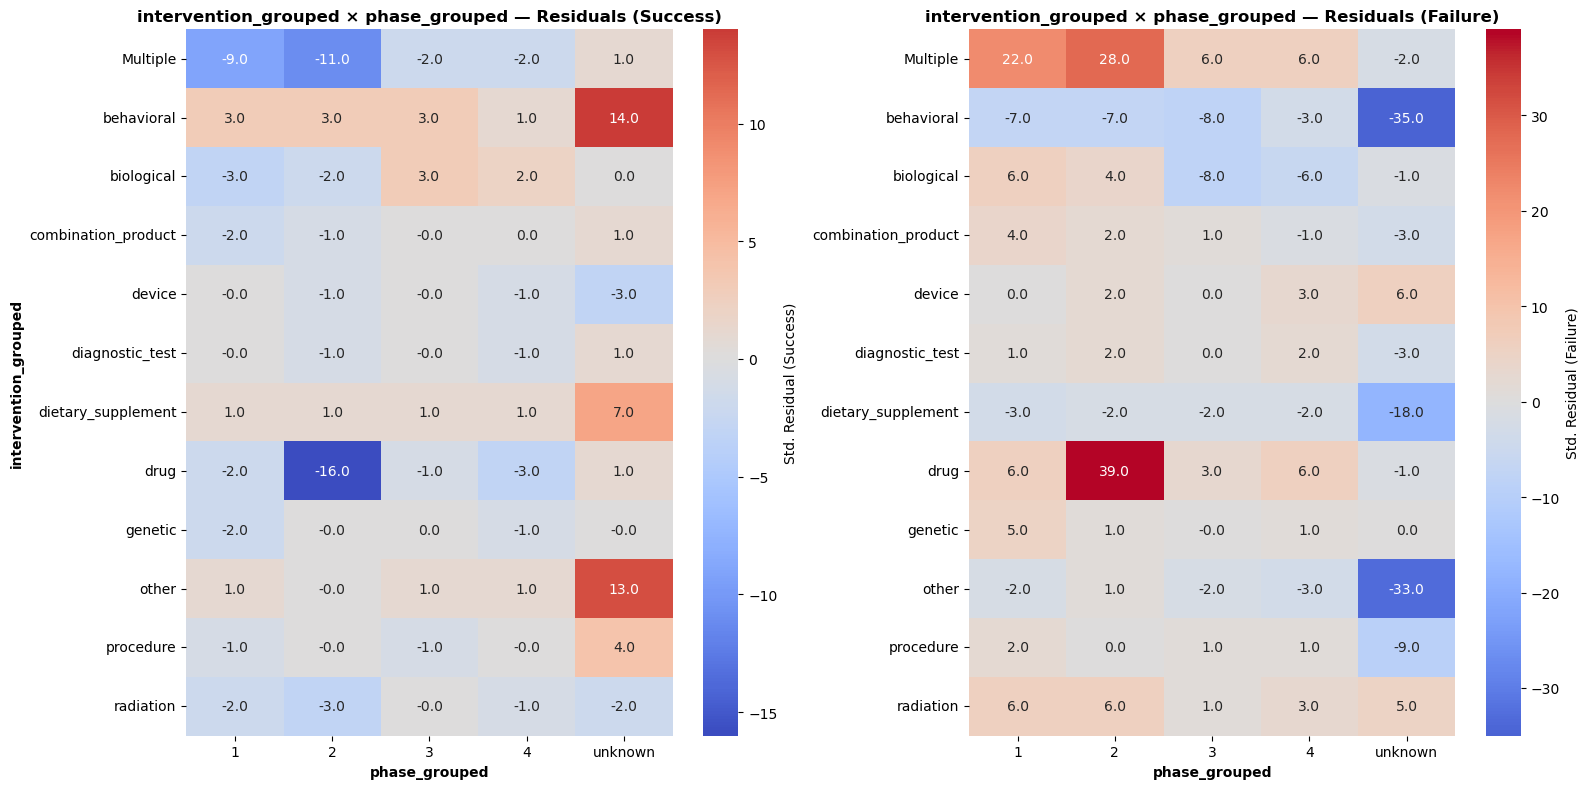

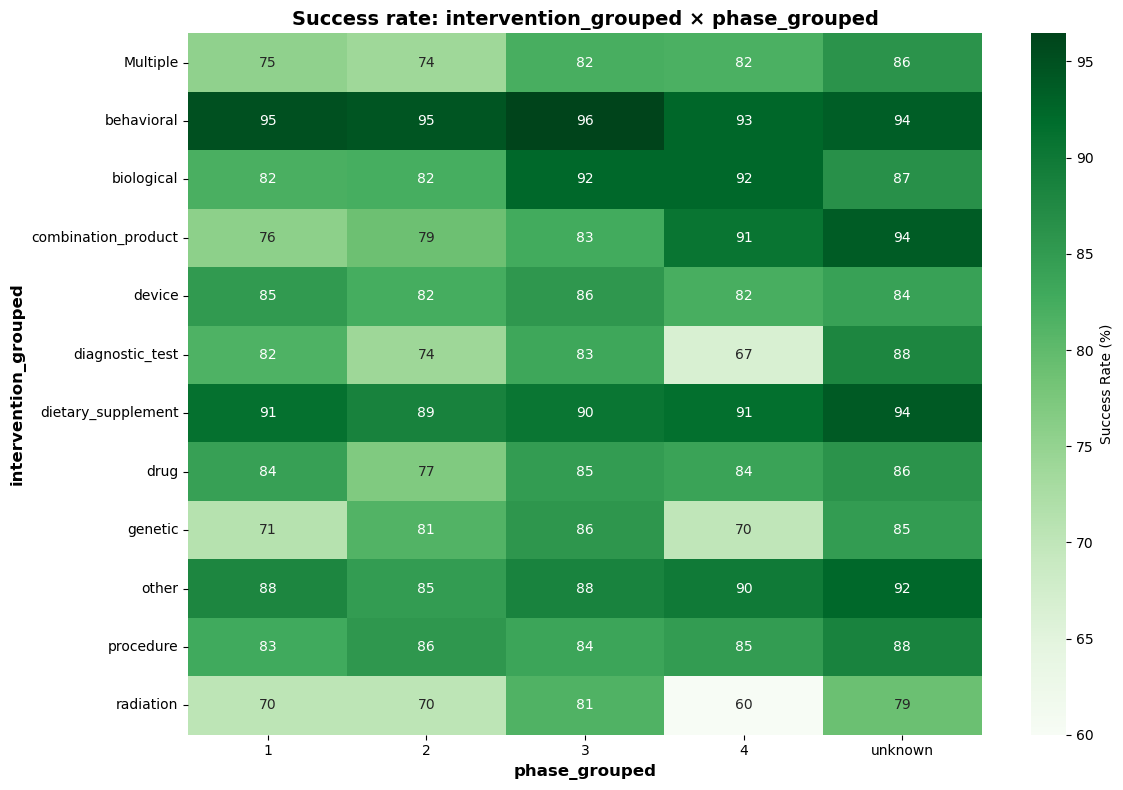

In [7]:
# Heatmaps for a specific pair
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'phase_grouped', show=True)

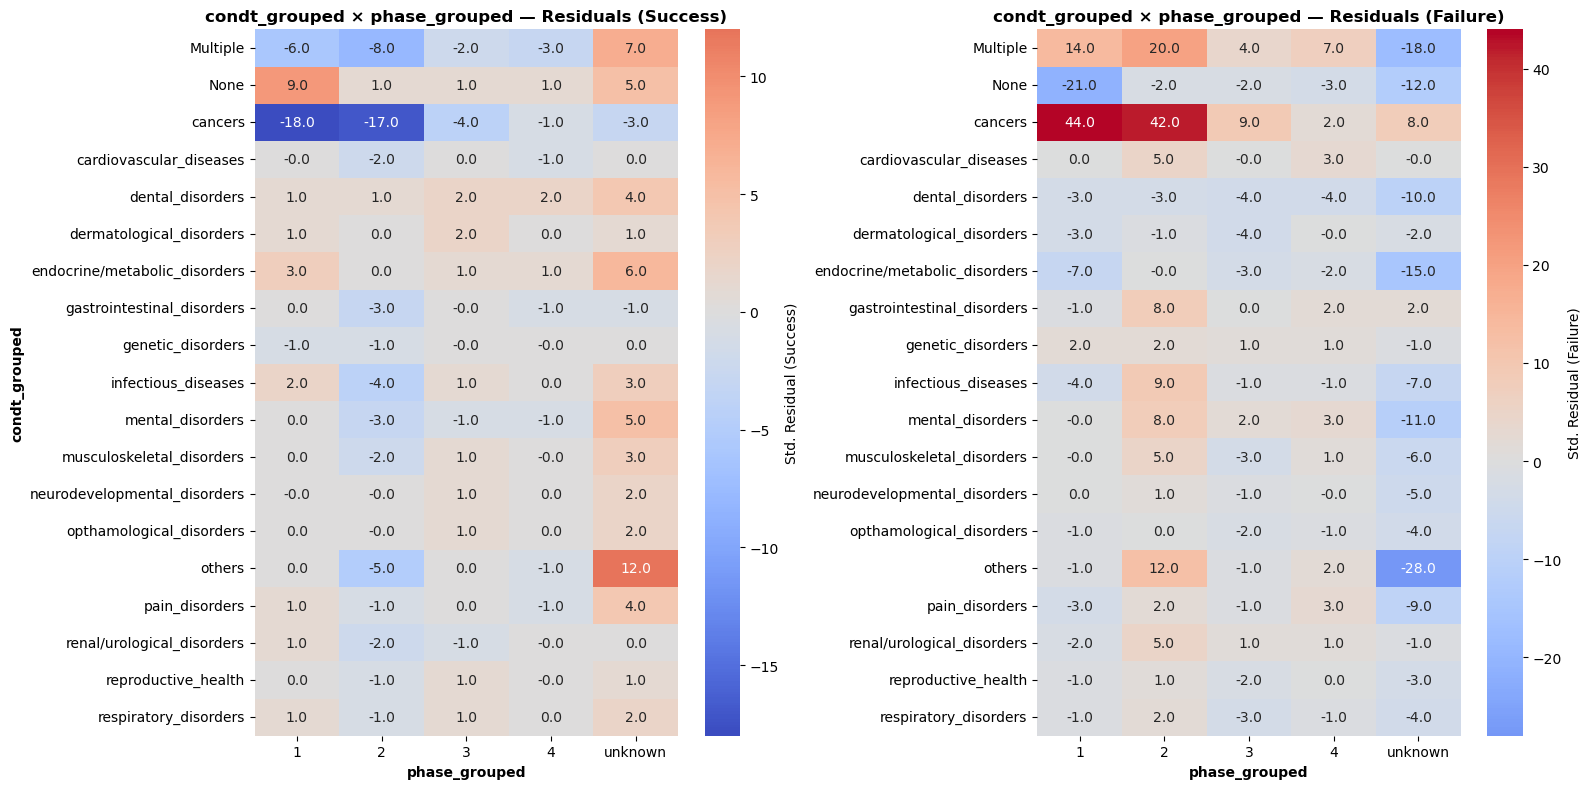

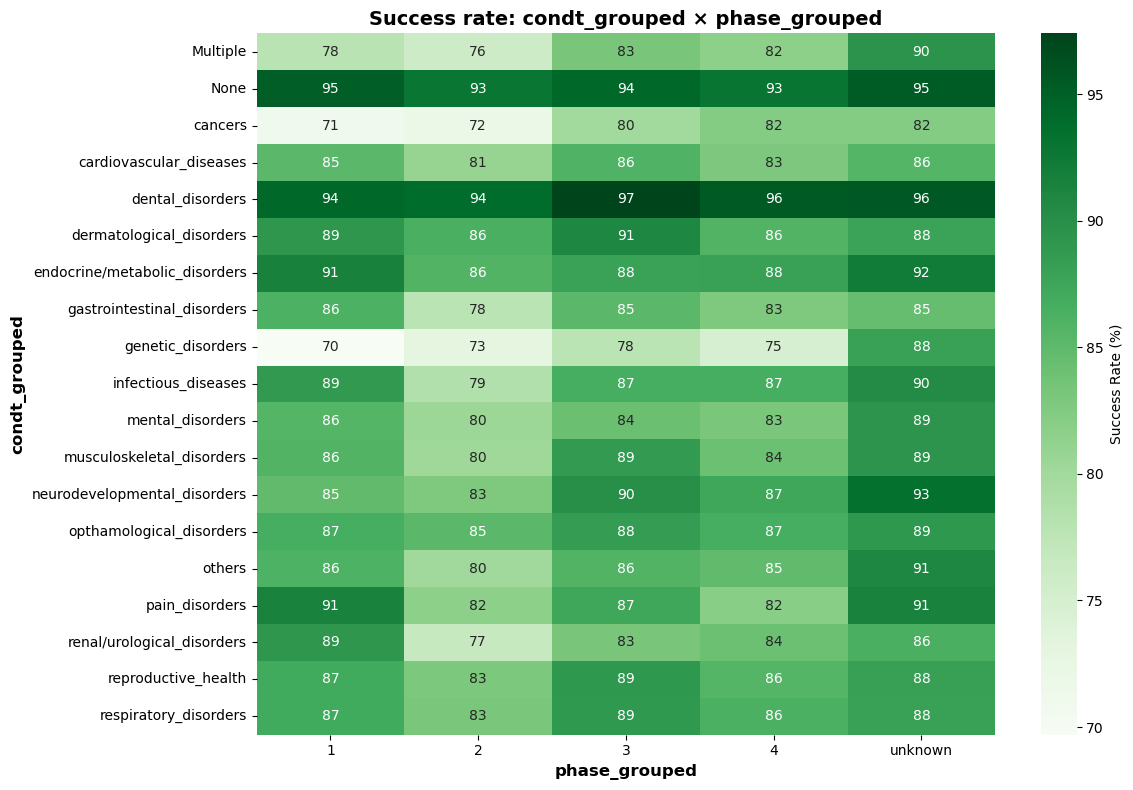

In [8]:
multivariate_cat_heatmaps(df_EDA_3, 'condt_grouped', 'phase_grouped', show=True)

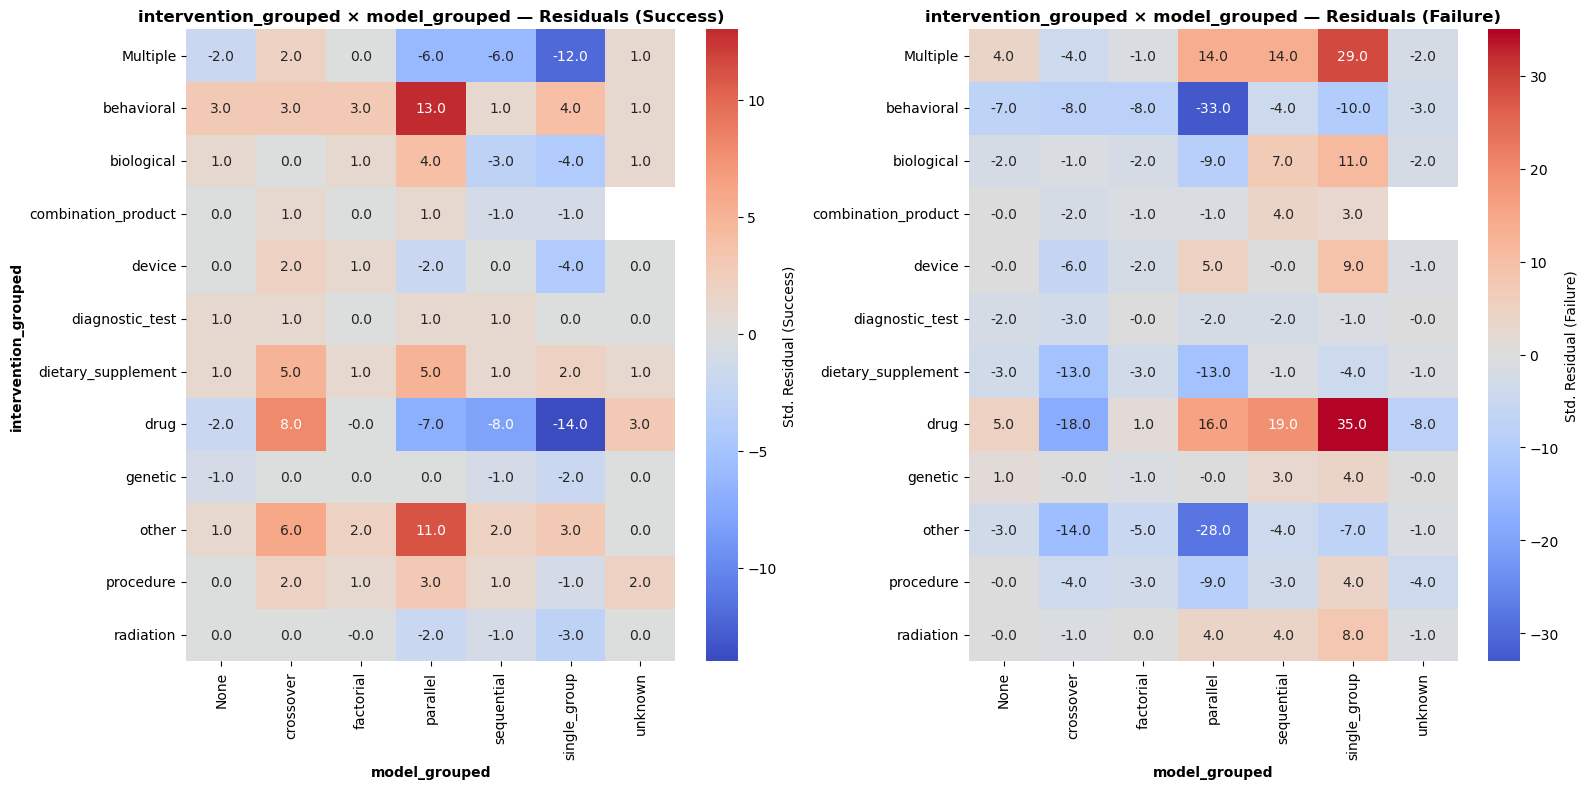

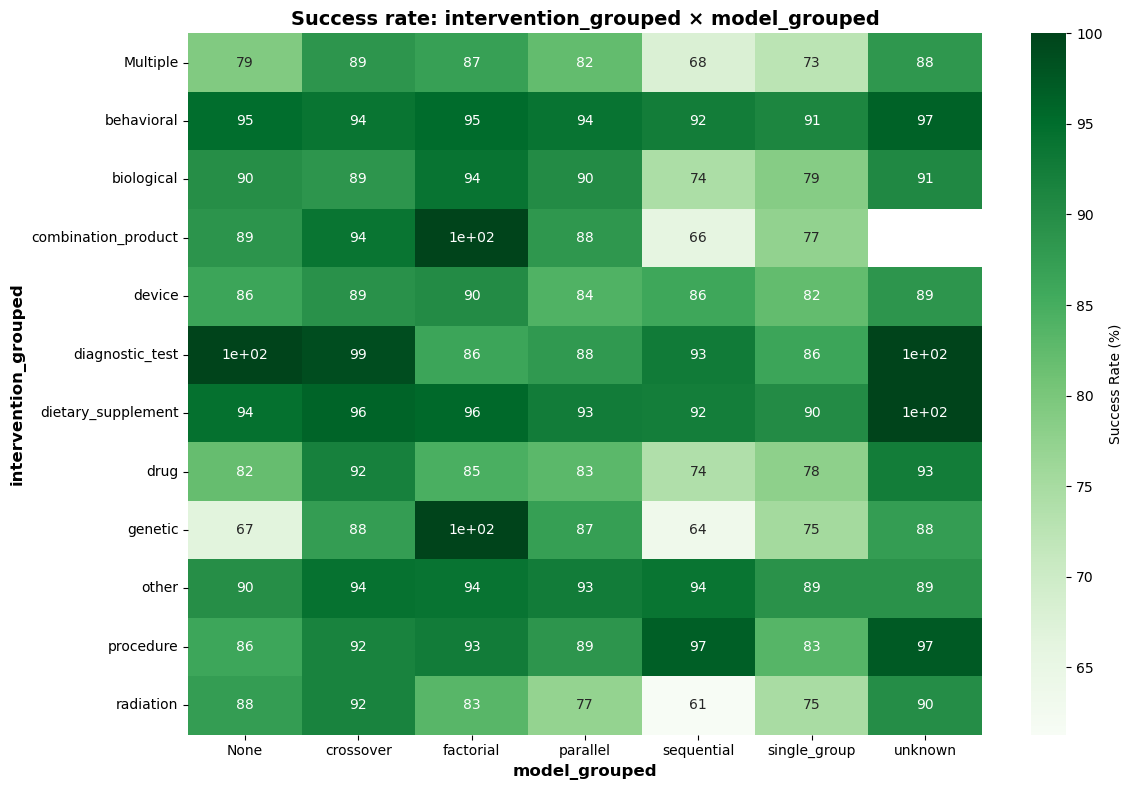

In [9]:
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'model_grouped', x_ticks = 90, show=True)

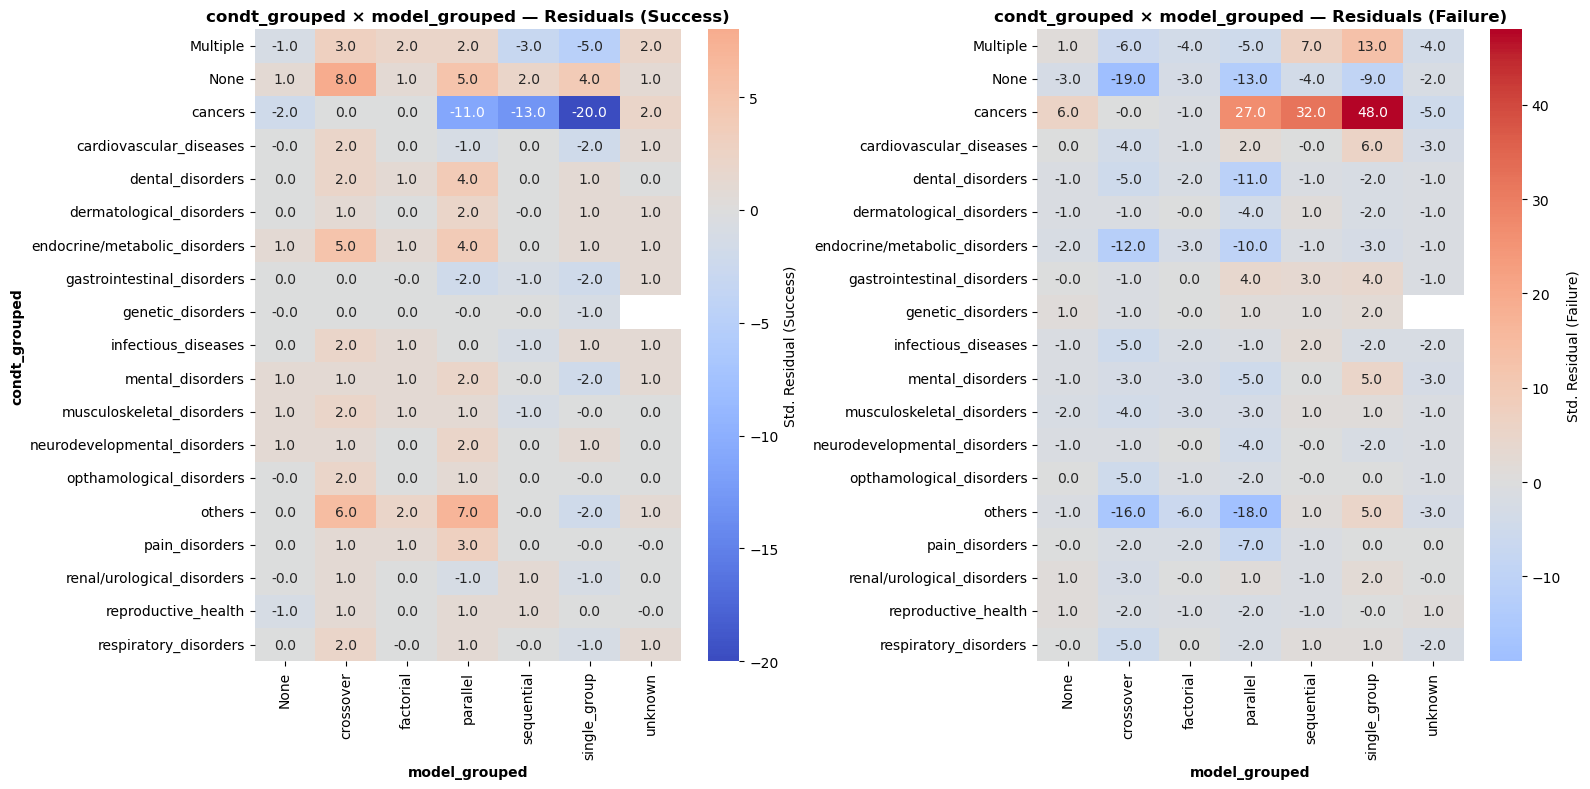

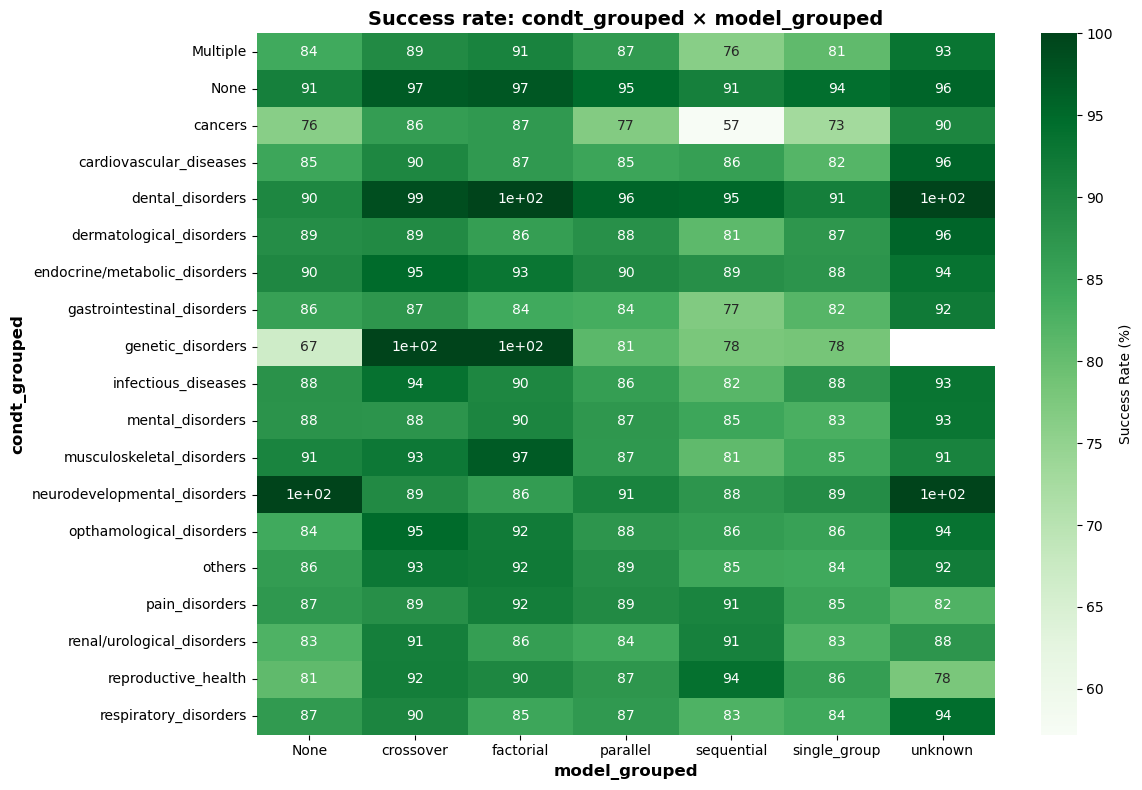

In [10]:

multivariate_cat_heatmaps(df_EDA_3, 'condt_grouped', 'model_grouped',  x_ticks = 90, show=True)

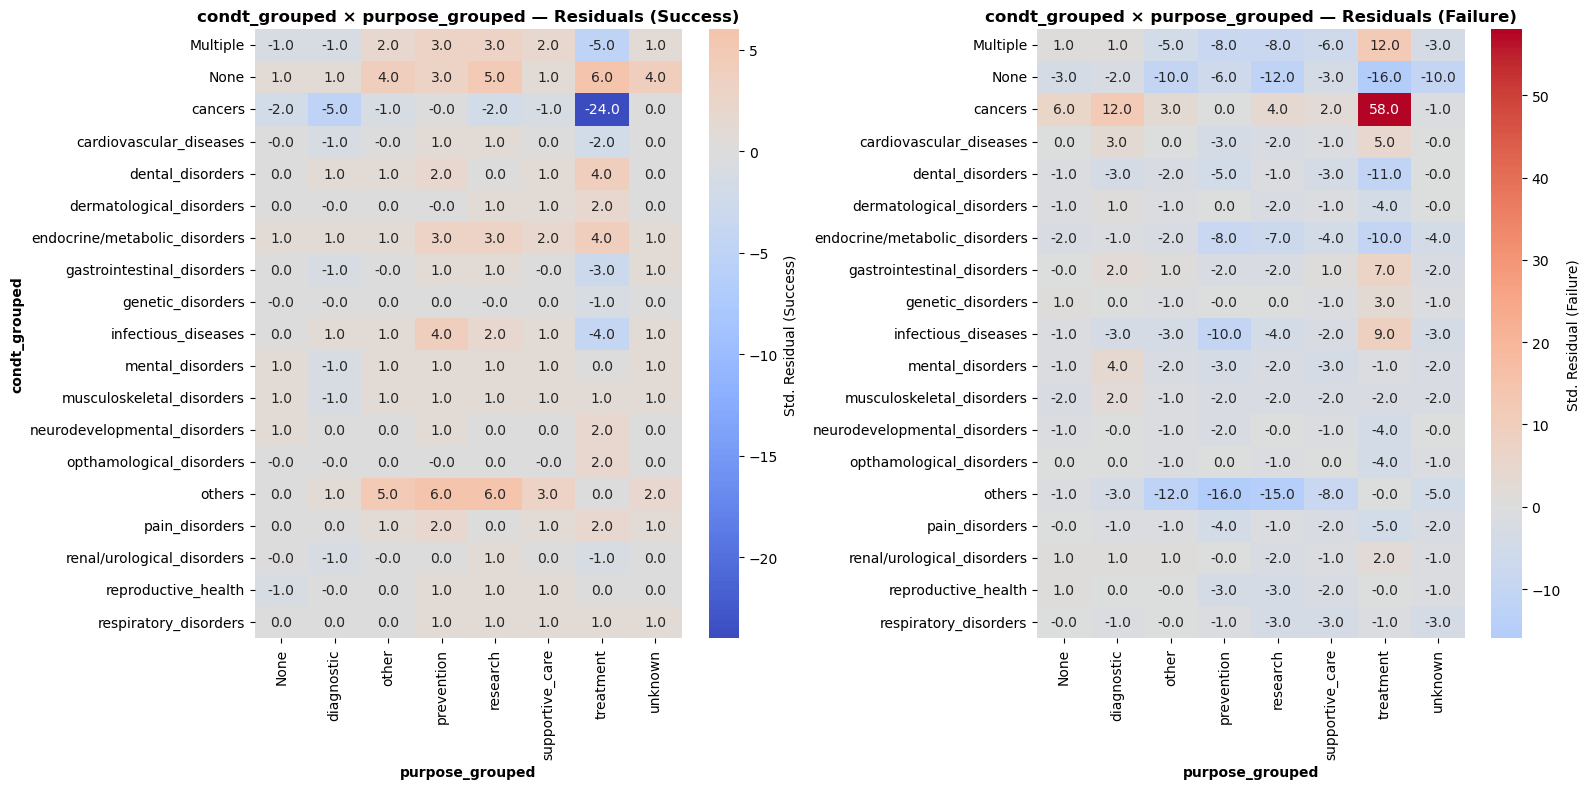

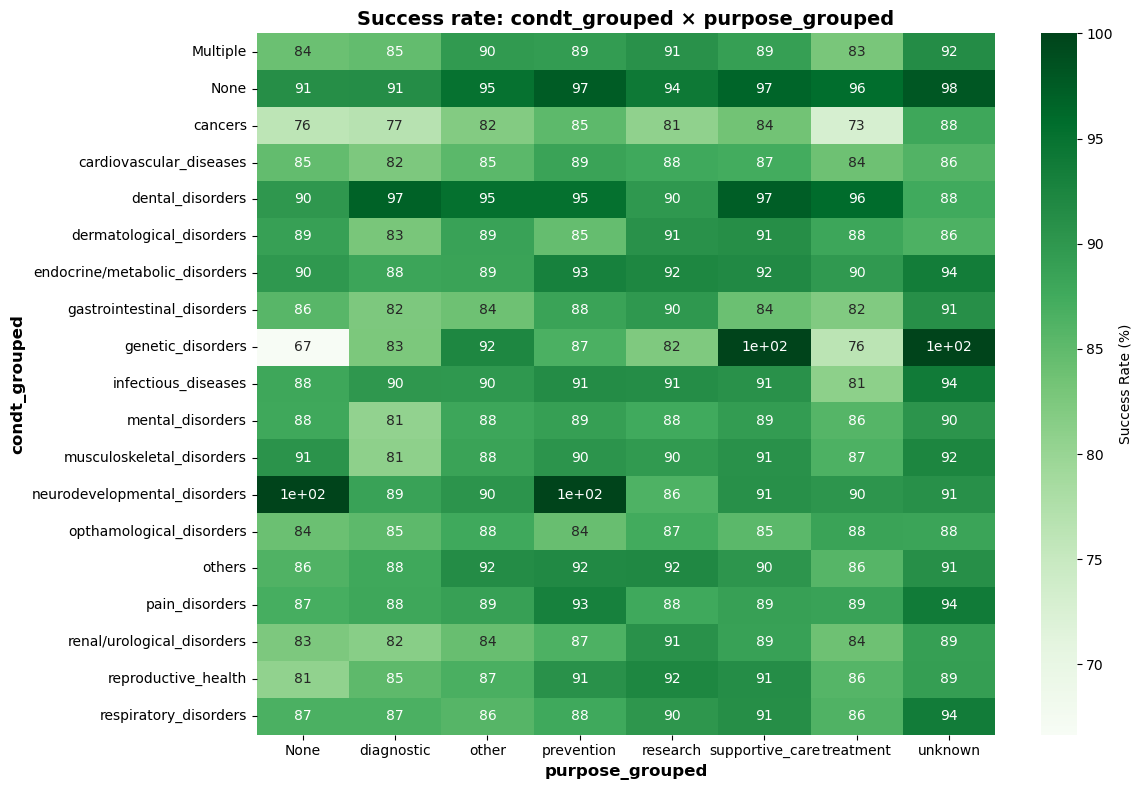

In [11]:
multivariate_cat_heatmaps(df_EDA_3, 'condt_grouped', 'purpose_grouped', x_ticks = 90, show=True)

In [12]:
# Save plots for remaining categorical pairs with Cramér’s V > 0.15
# 크래머의 V 값이 0.15보다 큰 나머지 범주형 쌍에 대한 그래프를 저장
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'condt_grouped', show=False)
multivariate_cat_heatmaps(df_EDA_3, 'model_grouped', 'phase_grouped', show=False)
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'allocation_grouped', show=False)
multivariate_cat_heatmaps(df_EDA_3, 'condt_grouped', 'masking_grouped', show=False)
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'purpose_grouped', x_ticks = 90, show=False)
multivariate_cat_heatmaps(df_EDA_3, 'phase_grouped', 'allocation_grouped', show=False)
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'masking_grouped', show=False)
multivariate_cat_heatmaps(df_EDA_3, 'intervention_grouped', 'phase_grouped', show=False)

,Category,Total_success,Total_failure,Median_success,IQR_success,Median_failure,IQR_failure,U_stat,p_value,Effect_size_r
0,3,25660,4397,247.0,428.0,48.0,234.0,8.34e+07,0,0.292
1,4,20015,3769,80.0,157.0,9.0,40.0,6.27e+07,0,0.419
2,unknown,119797,14001,60.0,99.0,5.0,29.0,1.40e+09,0,0.353
3,2,33892,9829,59.0,90.0,9.0,33.0,2.72e+08,0,0.458
4,1,39359,8043,31.0,38.0,7.0,23.0,2.52e+08,0,0.383


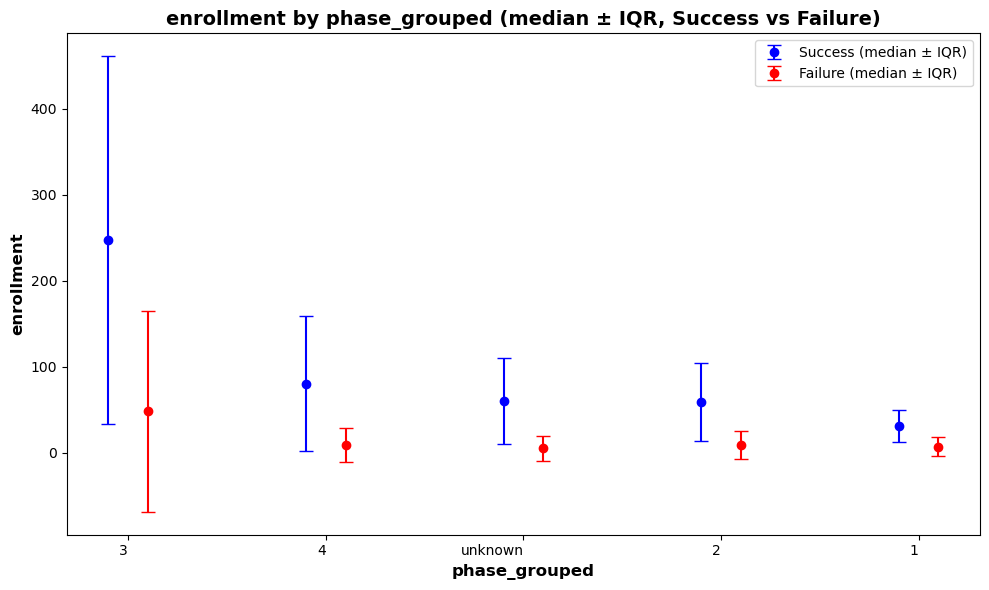

In [13]:
analysis_num_cat_target(df_EDA_3, cat_col = 'phase_grouped', num_col = 'enrollment', show = True)

,Category,Total_success,Total_failure,Median_success,IQR_success,Median_failure,IQR_failure,U_stat,p_value,Effect_size_r
0,factorial,3634,369,119.0,310.00,13.0,67.00,1.08e+06,5.2e-83,0.305
1,parallel,142597,21699,86.0,160.00,13.0,57.00,2.47e+09,0,0.351
2,None,5076,846,60.0,118.25,8.0,34.00,3.53e+06,2.8e-197,0.389
3,unknown,2991,274,47.0,76.50,28.0,56.25,5.52e+05,1.9e-21,0.166
4,sequential,5015,1540,43.0,64.00,12.0,31.00,5.99e+06,1.3e-235,0.405
5,single_group,55222,13244,31.0,50.00,5.0,18.00,5.99e+08,0,0.436
6,crossover,24188,2067,30.0,33.00,5.0,18.00,4.16e+07,0,0.310


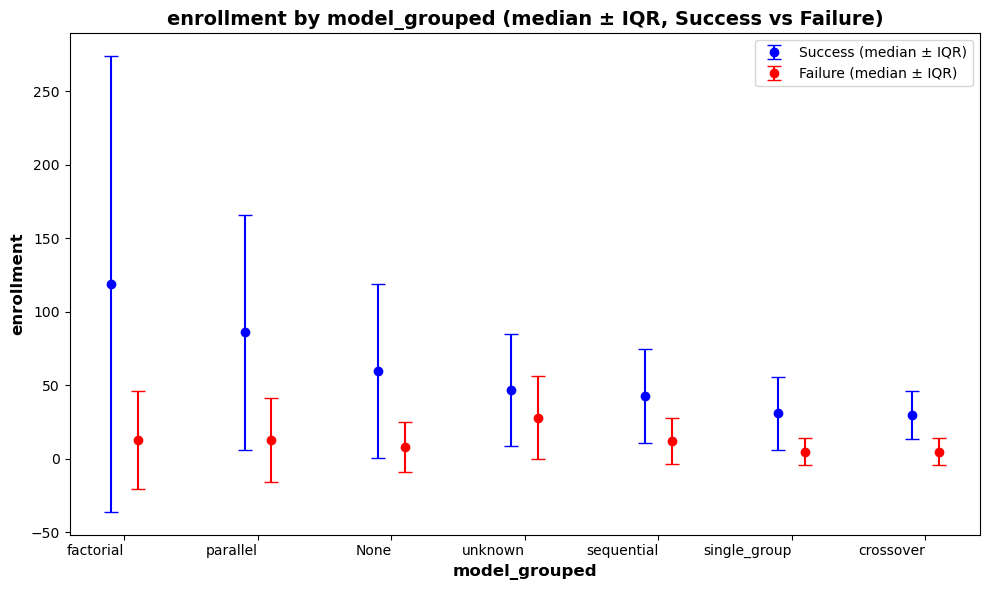

In [14]:
analysis_num_cat_target(df_EDA_3, cat_col = 'model_grouped', num_col = 'enrollment', show = True)

,Category,Total_success,Total_failure,Median_success,IQR_success,Median_failure,IQR_failure,U_stat,p_value,Effect_size_r
0,randomized,159158,22134,76.0,149.00,12.0,54.0,2.78e+09,0,0.328
1,None,5076,846,60.0,118.25,8.0,34.0,3.53e+06,2.8e-197,0.389
2,unknown,3415,493,39.0,37.00,12.0,32.0,1.25e+06,1.1e-69,0.282
3,non_randomized,71074,16566,35.0,57.00,6.0,20.0,9.55e+08,0,0.422


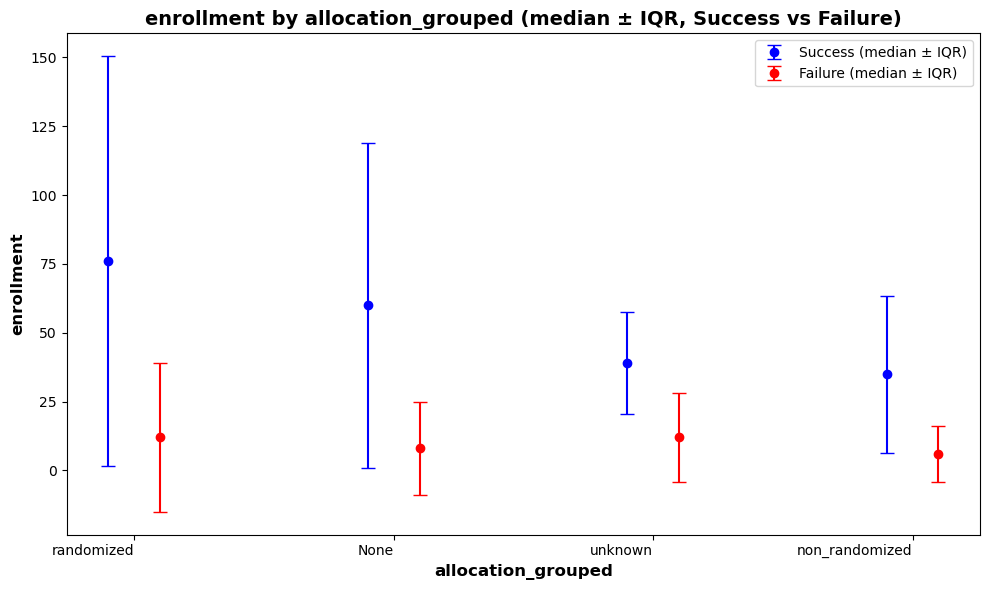

In [15]:
analysis_num_cat_target(df_EDA_3, cat_col = 'allocation_grouped', num_col = 'enrollment', show = True)

,Category,Total_success,Total_failure,Median_success,IQR_success,Median_failure,IQR_failure,U_stat,p_value,Effect_size_r
0,cancers,28798,9781,1461.0,1368.00,972.0,965.00,1.85e+08,0,0.236
1,genetic_disorders,168,41,877.5,922.25,974.0,891.00,3.59e+03,0.68,0.028
2,cardiovascular_diseases,11985,2159,760.0,973.00,760.0,901.00,1.30e+07,0.62,0.004
3,mental_disorders,21400,3353,731.0,913.00,699.0,808.00,3.78e+07,4.8e-07,0.032
4,Multiple,42101,7121,685.0,914.00,744.0,881.00,1.44e+08,1.9e-08,0.025
5,gastrointestinal_disorders,6735,1342,672.0,793.00,729.5,768.75,4.38e+06,0.073,0.020
6,musculoskeletal_disorders,7321,1083,671.0,843.00,731.0,888.50,3.75e+06,0.0047,0.031
7,neurodevelopmental_disorders,1142,124,670.0,882.75,603.0,826.00,7.61e+04,0.17,0.039
8,reproductive_health,3055,445,618.0,762.00,701.0,762.00,6.31e+05,0.015,0.041
9,renal/urological_disorders,3027,540,610.0,793.00,703.0,820.25,7.61e+05,0.011,0.043


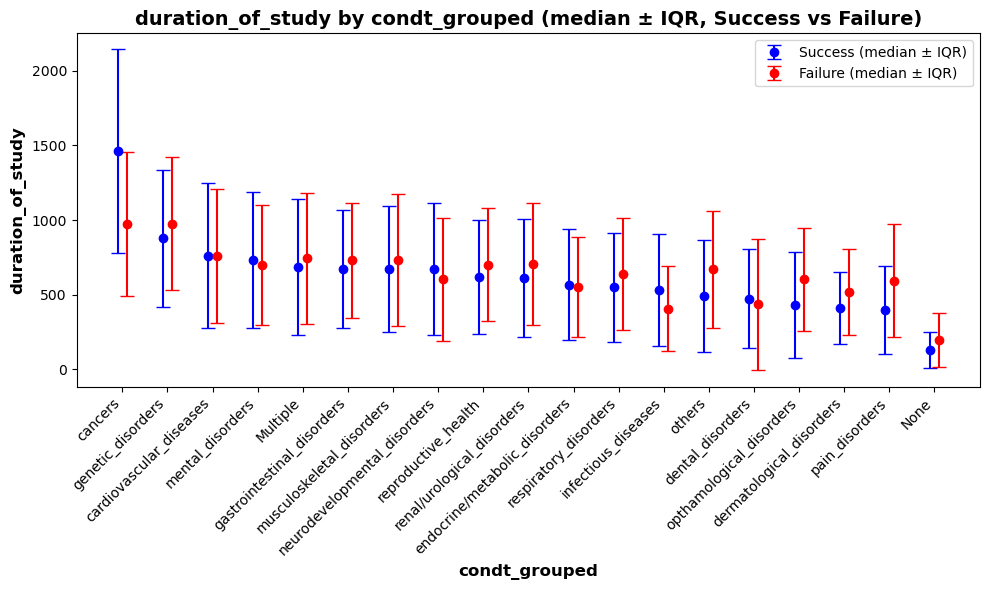

In [16]:
analysis_num_cat_target(df_EDA_3, cat_col = 'condt_grouped', num_col = 'duration_of_study', rotation = 45, show = True)

,Category,Total_success,Total_failure,Median_success,IQR_success,Median_failure,IQR_failure,U_stat,p_value,Effect_size_r
0,unknown,2991,274,1461.0,1550.00,863.0,1075.00,5.37e+05,1.9e-17,0.149
1,single_group,55222,13244,791.0,1110.00,769.0,917.00,3.69e+08,0.074,0.007
2,factorial,3634,369,790.0,1098.75,670.0,933.00,7.30e+05,0.0048,0.045
3,None,5076,846,641.0,913.00,670.0,823.75,2.15e+06,0.98,0.000
4,parallel,142597,21699,639.0,876.00,730.0,852.00,1.47e+09,5.6e-35,0.030
5,sequential,5015,1540,562.0,866.00,737.0,828.00,3.38e+06,2e-13,0.091
6,crossover,24188,2067,274.0,579.00,517.0,815.50,1.86e+07,6e-84,0.120


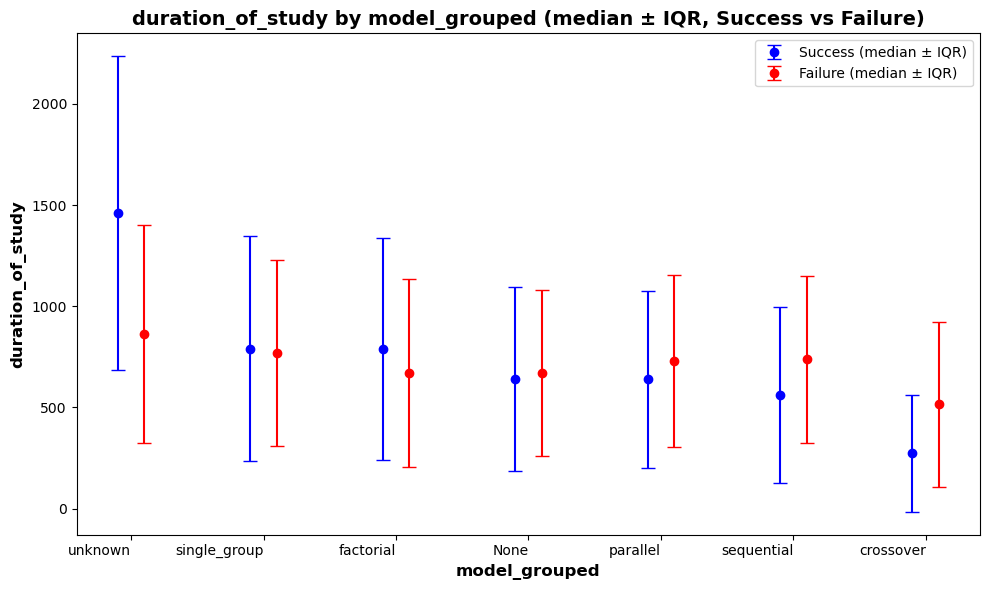

In [17]:
analysis_num_cat_target(df_EDA_3, cat_col = 'model_grouped', num_col = 'duration_of_study', show = True)

,Category,Total_success,Total_failure,Median_success,IQR_success,Median_failure,IQR_failure,U_stat,p_value,Effect_size_r
0,behavioral,28662,1940,88.0,185.0,5.0,31.00,4.77e+07,0,0.303
1,diagnostic_test,2032,283,80.0,156.0,4.0,36.50,4.82e+05,7.2e-76,0.383
2,biological,9082,1544,75.0,272.0,5.0,23.00,1.19e+07,0,0.425
3,procedure,14675,2047,60.0,88.0,6.0,39.00,2.43e+07,0,0.350
4,drug,88242,18706,60.0,122.0,11.0,41.00,1.29e+09,0,0.368
5,Multiple,29604,7115,60.0,110.0,7.0,30.00,1.74e+08,0,0.446
6,other,32714,2793,57.0,90.0,7.0,35.00,7.37e+07,0,0.286
7,device,23926,4529,50.0,80.0,6.0,30.00,8.71e+07,0,0.385
8,combination_product,658,124,49.0,75.0,2.5,11.25,7.17e+04,6.6e-41,0.479
9,genetic,286,77,48.0,144.0,5.0,12.00,1.81e+04,4e-18,0.455


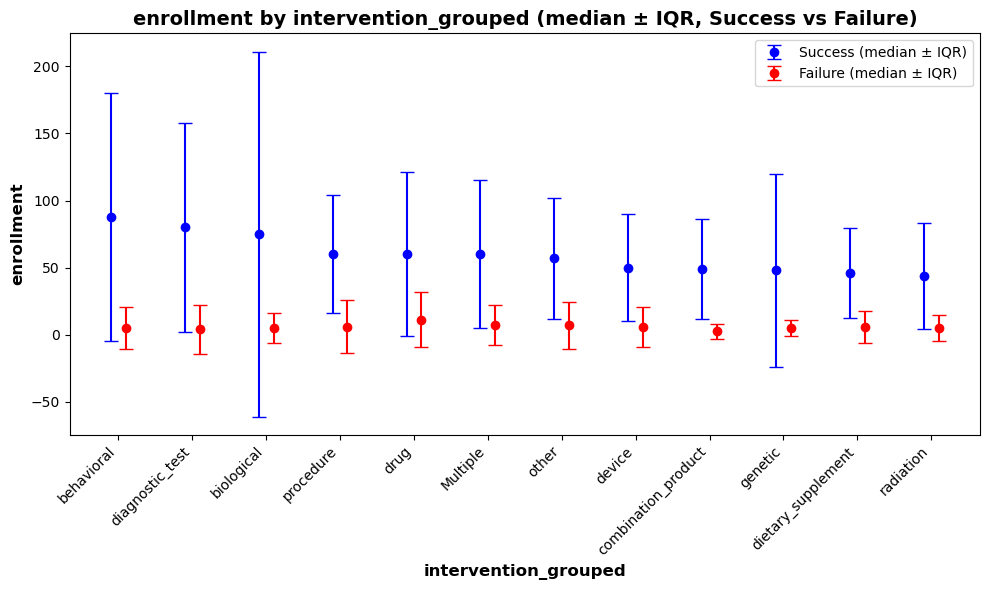

In [18]:
analysis_num_cat_target(df_EDA_3, cat_col = 'intervention_grouped', num_col = 'enrollment', rotation = 45, show = True)

In [19]:
# Export dataset for EDA Part 3
df_EDA_3.to_csv(DATA_PROCESSED / "df_EDA_3.csv", index=False)